In [180]:
# Load environment variables and set up auto-reload
from pathlib import Path
from dotenv import load_dotenv

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not find project root via pyproject.toml")

PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env.local", override=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
from notebooks.utils import show_prompt
from prompts import clarify_with_user_instructions
show_prompt(clarify_with_user_instructions, "Clarify with User Instructions")

╭──────────────────────────────────────── Clarify with User Instructions ─────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  These are the messages that have been exchanged so far from the user asking for economic database series       │
│  onboarding:                                                                                                    │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  A downstream verification step may have surfaced an identifier-vs-description conflict for the user to         │
│  resolve. If so, it is provided here:                                                                           │
│  <VerificationConflict>                                                                                         │
│  {verification_conflict}                                                                                        │
│  </VerificationConflict>                                                                                        │
│                                                                                                                 │
│  You have access to web_search tool:                                                                            │
│  1. **web_search**: you may use it to interpret unfamiliar terms or confirm that an identifier exists, only     │
│  when needed to decide whether the user's input is identifiable.                                                │
│                                                                                                                 │
│  Your task is to assess whether the user has provided enough information to identify the exact economic or      │
│  financial data series they want to onboard for the macro database.                                             │
│                                                                                                                 │
│  If <VerificationConflict> is non-empty, that is the only thing you should be asking about. Set                 │
│  need_clarification to true and write one concise question that states the verified conflict and asks the user  │
│  which interpretation to use (follow the identifier as canonically defined, or switch to a series that matches  │
│  their description). Do not re-evaluate the general criteria below.                                             │
│                                                                                                                 │
│  Otherwise, apply the core criteria:                                                                            │
│                                                                                                                 │
│  1. The request must concern economic or financial data.                                                        │
│  Examples include macroeconomic indicators, financial market prices, rates, spreads, indices, fund data,        │
│  company financials, exchange rates, commodities, credit data, monetary data, and fiscal data.                  │
│  If the request is not clearly for economic or financial data, ask the user to restate it as a data-series      │
│  request.                                                                                                       │
│                                                       

In [182]:
from prompts import transform_messages_into_series_brief_prompt

show_prompt(
    transform_messages_into_series_brief_prompt,
    "Transform Messages Into Series Brief Prompt",
)

╭────────────────────────────────── Transform Messages Into Series Brief Prompt ──────────────────────────────────╮
│                                                                                                                 │
│  You will be given a set of messages that have been exchanged so far between yourself and the user.             │
│                                                                                                                 │
│  Your job is to write a self-contained descriptive series onboarding handoff brief.                             │
│                                                                                                                 │
│  The messages that have been exchanged so far between yourself and the user are:                                │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  A prior verification step has surfaced confirmed information about the identifier. Treat this as               │
│  authoritative and do not redo the same verification work:                                                      │
│  <VerificationFindings>                                                                                         │
│  {verification_findings}                                                                                        │
│  </VerificationFindings>                                                                                        │
│                                                                                                                 │
│  This brief is not a research report and should not try to fully populate database fields. It should preserve   │
│  the user's intended series scope, source, specific requirements, and provide enough descriptive information    │
│  for a downstream agent to draft a governance-compatible series registration proposal.                          │
│  The brief is a handoff artifact, not a conversation summary. Include only context that helps the downstream    │
│  drafter identify the data series and write accurate metadata.                                                  │
│                                                                                                                 │
│  You are a pure author at this step. By the time you run, the prior nodes have already ensured the input is     │
│  identifiable and that the identifier is consistent with the user's description. You do not gate, vote, or ask  │
│  for clarification.                                                                                             │
│                                                                                                                 │
│  You have access to web_search tool:                                                                            │
│  1. **web_search**: For filling in attributes that <VerificationFindings> did not cover. Do not re-verify what  │
│  is already in <VerificationFindings>.                                                                          │
│                                                                                                                 │
│  Guidelines:                                                                                                    │
│                                                                                                                 │
│  1. Capture the user's requested series                                                                         │
│  * State the data series or set of series the user wan

In [183]:
%%writefile state_scope.py

"""State Definitions and Pydantic Schemas for Scoping.

State objects and structured-output schemas for the scoping workflow:
  - clarify_with_user   -> owns clarification_*
  - verify_identifier   -> owns verification_*
  - write_series_brief  -> owns series_brief

Fields are namespaced per node so responsibilities do not leak between them.

All schema classes set `extra="forbid"` so Pydantic emits
`additionalProperties: false` in the generated JSON schema. OpenAI's strict
structured-output mode (used by the Responses API with tools) requires this
on every object, including nested objects in `$defs`.
"""

from typing_extensions import Optional, List

from langgraph.graph import MessagesState
from pydantic import BaseModel, ConfigDict, Field


# ===== STATE DEFINITIONS =====

class AgentInputState(MessagesState):
    """Input state for the full agent - only contains messages from user input."""
    pass


class AgentState(MessagesState):
    """Main state for the scoping workflow.

    Fields are namespaced per node so each node owns one slice of state:
      - clarify_with_user  -> need_clarification, clarification_question, clarification_reasons
      - verify_identifier  -> verification_findings, verification_conflict, verification_attempts
      - write_series_brief -> series_brief
    """

    # clarify_with_user
    need_clarification: Optional[bool]
    clarification_question: Optional[str]
    clarification_reasons: List[str]

    # verify_identifier
    verification_findings: Optional["VerificationFindings"]
    verification_conflict: Optional[str]
    verification_attempts: int

    # write_series_brief
    series_brief: Optional[str]


# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decision and questions."""

    model_config = ConfigDict(extra="forbid")

    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="If need_clarification is True, a question to ask the user to clarify the onboarding series scope. Empty otherwise.",
    )
    verification: str = Field(
        description="If need_clarification is False, a message confirming that we will start series onboarding after the user has provided the necessary information. Empty otherwise.",
    )


class VerificationFindings(BaseModel):
    """Byproduct of identifier verification, reusable by write_series_brief.

    Only what verify_identifier surfaces while testing the conflict hypothesis.
    Brief writer fills the remaining gaps; verify_identifier must not drift into
    full attribute collection.
    """

    canonical_name: str = Field(
        default="",
        description="Canonical name confirmed via verification (e.g., 'Core CPI, seasonally adjusted'). Empty if not determined.",
    )
    source_url: str = Field(
        default="",
        description="Authoritative source URL surfaced during verification (e.g., the FRED series page). Empty if not found.",
    )
    notes: str = Field(
        default="",
        description="Short free-text notes captured as a byproduct (e.g., 'monthly, index 1982-1984=100'). Not exhaustive.",
    )


class VerifyIdentifier(BaseModel):
    """Schema for identifier-vs-description verification."""

    model_config = ConfigDict(extra="forbid")

    has_conflict: bool = Field(
        description="True if the identifier (e.g., FRED ticker) does not match the user's description.",
    )
    conflict_description: str = Field(
        default="",
        description="Short description of the mismatch, suitable for asking the user to resolve (e.g., 'CPILFESL is core CPI, but you asked for headline inflation'). Empty if no conflict.",
    )
    findings: VerificationFindings = Field(
        default_factory=VerificationFindings,
        description="Verified attributes surfaced during the conflict check. Passed forward so write_series_brief does not redo the same web searches.",
    )


class SeriesBrief(BaseModel):
    """Schema for series brief generation.

    Brief writer is a pure author: it produces the artifact and does not vote
    on whether more clarification is needed. That decision lives in
    clarify_with_user, gated by verify_identifier.
    """

    model_config = ConfigDict(extra="forbid")

    series_brief: str = Field(
        description="A brief description of the economic or financial data series to be onboarded.",
    )

Overwriting state_scope.py


In [184]:
%%writefile onboarding_scope.py

"""Series onboarding scoping workflow.

Three-node scoping graph:
  - clarify_with_user: completeness check. Asks the user for missing info.
  - verify_identifier: identifier-vs-description conflict check via web_search.
  - write_series_brief: pure author of the onboarding handoff brief.

The back-edge from verify_identifier to clarify_with_user is bounded by
MAX_VERIFICATION_ATTEMPTS to prevent infinite loops on ambiguous cases.

All `with_structured_output` calls pass `strict=True`. This makes langchain
convert the schema to OpenAI's strict format on the wire, which guarantees
`additionalProperties: false` on every object regardless of whether the
Pydantic class was imported with `ConfigDict(extra="forbid")` (defense
against stale module caches when running under `langgraph dev`).

The model is built with `streaming=False`. langchain-openai's streaming code
path for the Responses API does not apply the strict schema conversion that
`with_structured_output(..., strict=True)` requires, so OpenAI rejects the
schema as missing `additionalProperties: false`. The non-streaming path
builds the payload correctly. langgraph still streams at the graph-event
level; this only forces each LLM call to be a single synchronous request.

verification_conflict is a single-use slot. clarify_with_user consumes it on
entry (captures it into a local variable for the prompt) and unconditionally
clears it on exit. Without this discipline, the slot would persist across
user turns and the clarification prompt's "if non-empty, ask only about this"
rule would keep re-asking the same conflict question on every turn,
regardless of the user's answer. The conflict context survives in the
message history; verify_identifier re-detects any unresolved mismatch from
the updated transcript.
"""

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, get_buffer_string
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command

try:
    from macro_foundry.onboarding_agent.prompts import (
        clarify_with_user_instructions,
        transform_messages_into_series_brief_prompt,
        verify_identifier_instructions,
    )
    from macro_foundry.onboarding_agent.state_scope import (
        AgentInputState,
        AgentState,
        ClarifyWithUser,
        SeriesBrief,
        VerificationFindings,
        VerifyIdentifier,
    )
except ModuleNotFoundError:
    from prompts import (
        clarify_with_user_instructions,
        transform_messages_into_series_brief_prompt,
        verify_identifier_instructions,
    )
    from state_scope import (
        AgentInputState,
        AgentState,
        ClarifyWithUser,
        SeriesBrief,
        VerificationFindings,
        VerifyIdentifier,
    )


MAX_VERIFICATION_ATTEMPTS = 2


def get_model():
    """Build the model lazily so importing the module does not require credentials.

    `streaming=False` is required: see module docstring.
    """
    return init_chat_model(
        model="openai:gpt-5.1",
        temperature=1,
        use_responses_api=True,
        streaming=False,
    )


def _format_findings(findings: VerificationFindings | None) -> str:
    """Render verification findings for prompt interpolation."""
    if findings is None:
        return "(no prior verification findings)"
    parts = []
    if findings.canonical_name:
        parts.append(f"canonical_name: {findings.canonical_name}")
    if findings.source_url:
        parts.append(f"source_url: {findings.source_url}")
    if findings.notes:
        parts.append(f"notes: {findings.notes}")
    return "\n".join(parts) if parts else "(no prior verification findings)"


def clarify_with_user(state: AgentState) -> Command[Literal["verify_identifier", "__end__"]]:
    """Completeness gate. Asks the user for missing info or resolves a surfaced conflict.

    If verification_conflict is set, the question targets that conflict only;
    otherwise the general identification criteria apply.

    verification_conflict is a single-use slot: this node consumes it on entry
    (captured into a local variable for the prompt) and unconditionally clears
    it on exit via `cleared_slots`. Every exit Command merges in `cleared_slots`,
    so neither branch can leak the flag to the next turn. The conflict context
    survives in the message history; verify_identifier will re-detect any
    unresolved mismatch from the updated transcript.
    """
    conflict_input = state.get("verification_conflict") or ""

    structured_output_model = get_model().with_structured_output(
        ClarifyWithUser,
        tools=[{"type": "web_search"}],
        strict=True,
    )

    response = structured_output_model.invoke([
        HumanMessage(
            content=clarify_with_user_instructions.format(
                messages=get_buffer_string(messages=state["messages"]),
                verification_conflict=conflict_input,
            )
        )
    ])

    cleared_slots = {
        "verification_conflict": "",
        "clarification_reasons": [],
    }

    if response.need_clarification:
        return Command(
            goto=END,
            update={
                **cleared_slots,
                "need_clarification": True,
                "clarification_question": response.question,
                "messages": [AIMessage(content=response.question)],
            },
        )

    return Command(
        goto="verify_identifier",
        update={
            **cleared_slots,
            "need_clarification": False,
            "clarification_question": "",
            "messages": [AIMessage(content=response.verification)],
        },
    )


def verify_identifier(state: AgentState) -> Command[Literal["clarify_with_user", "write_series_brief"]]:
    """Web-verify that the identifier matches the user's description.

    On conflict, route back to clarify_with_user with a specific conflict context,
    up to MAX_VERIFICATION_ATTEMPTS. After the cap, proceed to write_series_brief
    with the unresolved conflict surfaced rather than looping further.
    """
    structured_output_model = get_model().with_structured_output(
        VerifyIdentifier,
        tools=[{"type": "web_search"}],
        strict=True,
    )

    response = structured_output_model.invoke([
        HumanMessage(
            content=verify_identifier_instructions.format(
                messages=get_buffer_string(messages=state["messages"]),
            )
        )
    ])

    attempts = state.get("verification_attempts", 0) + 1

    if response.has_conflict and attempts <= MAX_VERIFICATION_ATTEMPTS:
        bounce_message = (
            "Identifier verification surfaced a conflict that needs the user to resolve:\n"
            f"{response.conflict_description}"
        )
        return Command(
            goto="clarify_with_user",
            update={
                "verification_findings": response.findings,
                "verification_conflict": response.conflict_description,
                "verification_attempts": attempts,
                "messages": [AIMessage(content=bounce_message)],
            },
        )

    if response.has_conflict:
        forced_message = (
            f"Identifier verification still reports a conflict after {MAX_VERIFICATION_ATTEMPTS} attempts: "
            f"{response.conflict_description}. Proceeding to brief; the downstream agent should treat the conflict as unresolved."
        )
        return Command(
            goto="write_series_brief",
            update={
                "verification_findings": response.findings,
                "verification_conflict": response.conflict_description,
                "verification_attempts": attempts,
                "messages": [AIMessage(content=forced_message)],
            },
        )

    return Command(
        goto="write_series_brief",
        update={
            "verification_findings": response.findings,
            "verification_conflict": "",
            "verification_attempts": attempts,
        },
    )


def write_series_brief(state: AgentState) -> Command[Literal["__end__"]]:
    """Pure author of the onboarding handoff brief.

    Reads verification_findings as authoritative and fills gaps via targeted
    web_search. Does not gate or vote on clarification.
    """
    structured_output_model = get_model().with_structured_output(
        SeriesBrief,
        tools=[{"type": "web_search"}],
        strict=True,
    )

    response = structured_output_model.invoke([
        HumanMessage(
            content=transform_messages_into_series_brief_prompt.format(
                messages=get_buffer_string(state.get("messages", [])),
                verification_findings=_format_findings(state.get("verification_findings")),
            )
        )
    ])

    brief_message = (
        "The following series brief has been generated based on the conversation history:\n\n\n"
        f"{response.series_brief}"
    )

    return Command(
        goto=END,
        update={
            "series_brief": response.series_brief,
            "messages": [AIMessage(content=brief_message)],
        },
    )


series_scope_builder = StateGraph(AgentState, input_schema=AgentInputState)
series_scope_builder.add_node("clarify_with_user", clarify_with_user)
series_scope_builder.add_node(
    "verify_identifier",
    verify_identifier,
    destinations=("clarify_with_user", "write_series_brief"),
)
series_scope_builder.add_node("write_series_brief", write_series_brief)
series_scope_builder.add_edge(START, "clarify_with_user")

scope_series_onboarding = series_scope_builder.compile()

Overwriting onboarding_scope.py


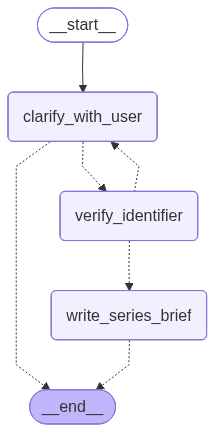

In [185]:
# Compile with in-memory checkpointer to test in notebook
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from onboarding_scope import series_scope_builder

checkpointer = InMemorySaver()
scope = series_scope_builder.compile(checkpointer=checkpointer)
display(Image(scope.get_graph(xray=True).draw_mermaid_png()))

In [186]:
# # Run the workflow
# from notebooks.utils import format_messages
# from langchain_core.messages import HumanMessage

# thread = {"configurable": {"thread_id": "1"}}
# result = scope.invoke(
#     {"messages": [HumanMessage(content="I want to onboard US core CPI series CPIAUCSL")]},
#     config=thread,
# )
# format_messages(result["messages"])


In [187]:
# from rich.markdown import Markdown
# Markdown(result["series_brief"])